<a href="https://colab.research.google.com/github/Razaurrahmanbennett/CSET_343/blob/main/LAB_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#RAZAUR RAHMAN
#E23CSEU2442



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.8 MB/s eta 0:00:00
Libraries imported successfully.

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Shape:
(768, 9)

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
I

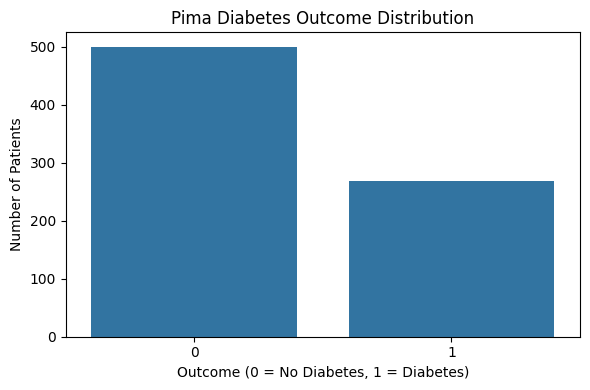


Zero Values Before Cleaning:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Missing Values After Converting Zero to NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Missing Values After Imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


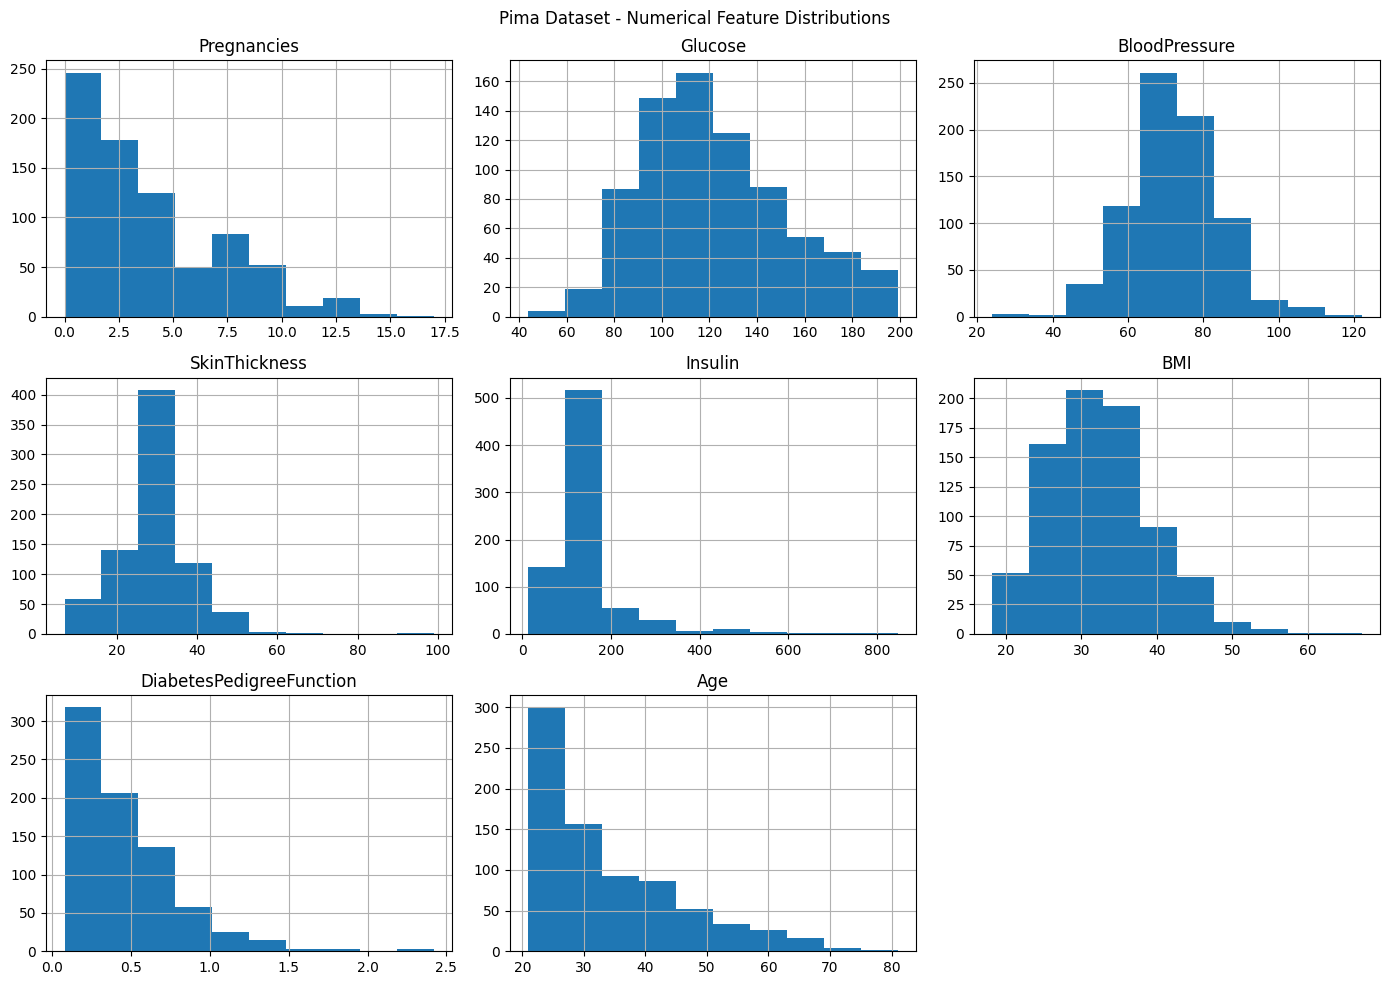

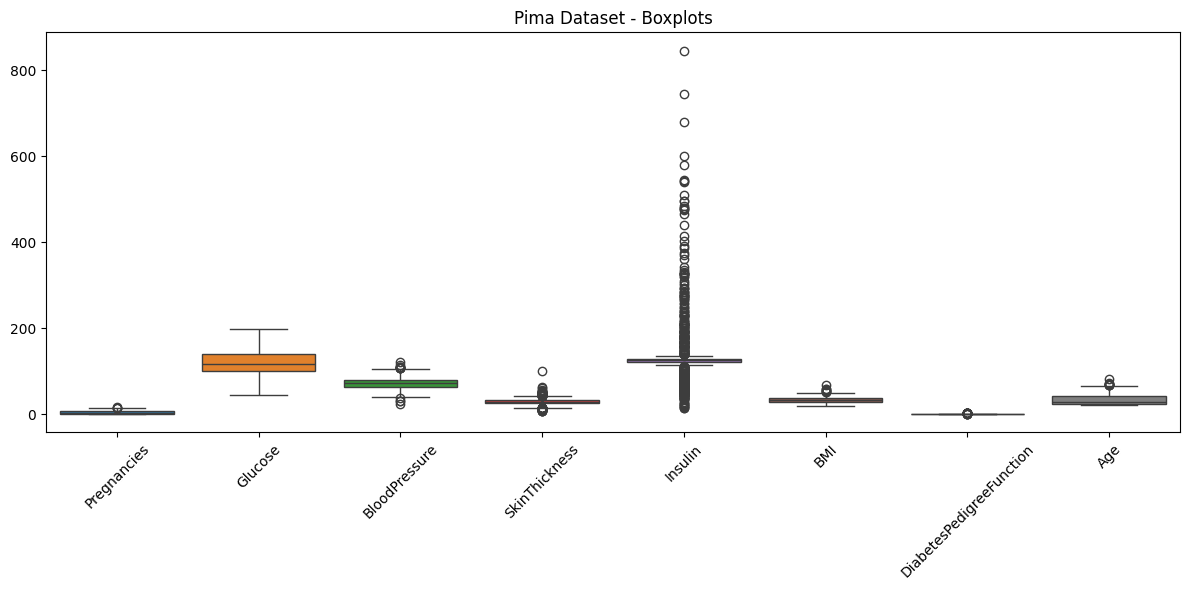

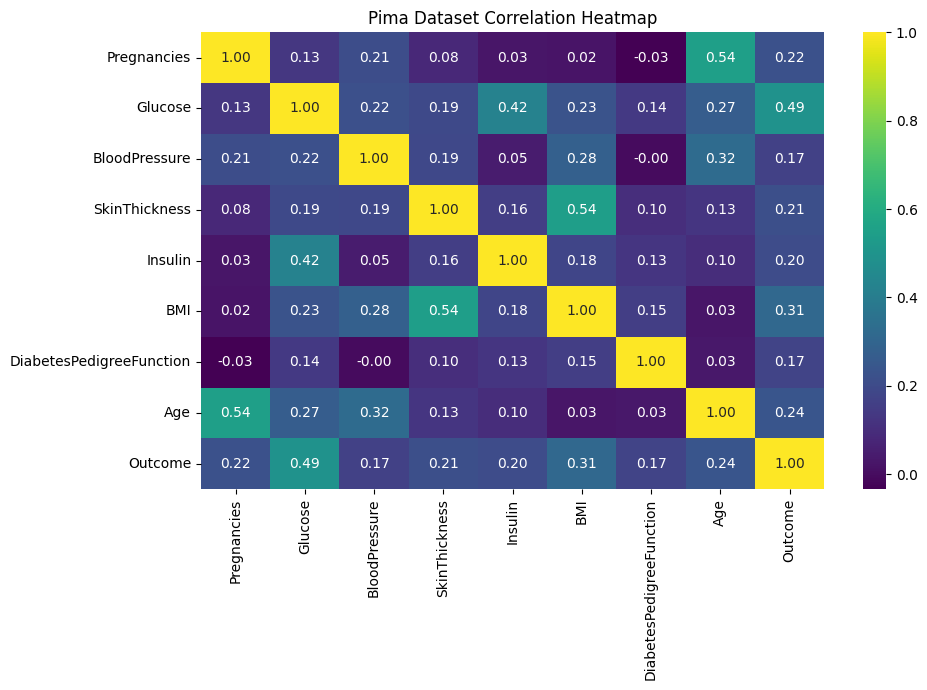


Pregnancy Categories:
Preg_Cat
Low       349
Medium    250
High      169
Name: count, dtype: int64

Selected Features:
['Pregnancies', 'Glucose', 'SkinThickness', 'BMI', 'Age']

Independent T-Test
T-statistic: -14.8527
P-value: 3.5421485614431447e-41
Result: Reject the null hypothesis.

Contingency Table:
Outcome     0   1
Preg_Cat         
Low       263  86
Medium    163  87
High       74  95

Chi-Square Test
Chi-square: 49.9568
P-value: 1.4191051932018717e-11
Degrees of freedom: 2
Result: Reject the null hypothesis.

ANOVA - BMI across Pregnancy Categories
                   sum_sq     df         F    PR(>F)
C(Preg_Cat)    164.199183    2.0  1.740246  0.176171
Residual     36090.399983  765.0       NaN       NaN

PART B - TEXTUAL DATA

First 5 rows:
   Unnamed: 0                                        description  \
0           0   A 23-year-old white female presents with comp...   
1           1           Consult for laparoscopic gastric bypass.   
2           2           Consult f

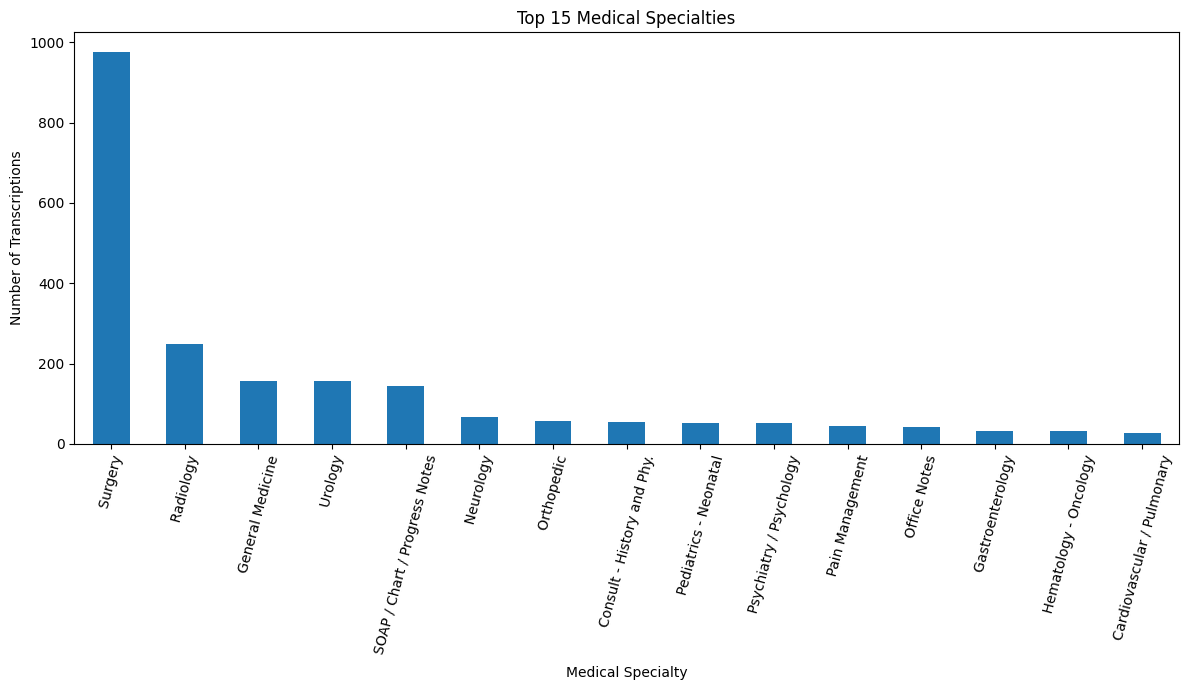


Average Transcription Length: 3005.4344505727618
Maximum Transcription Length: 18425
Minimum Transcription Length: 11


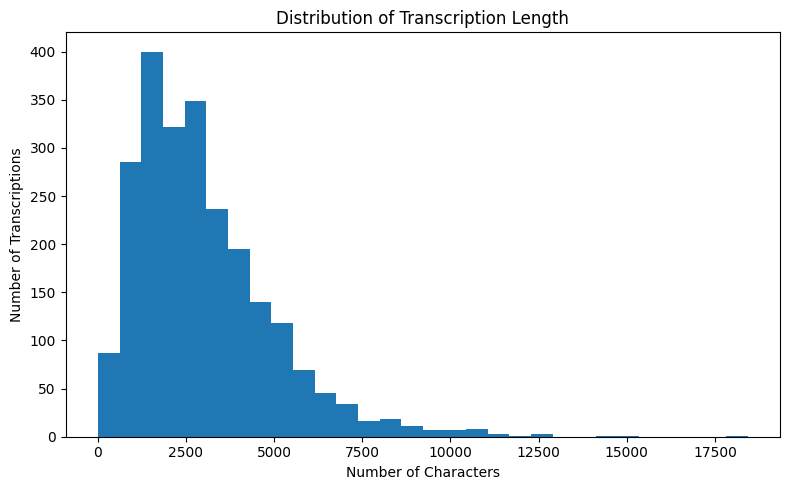


Example After PHI Removal:
                                       transcription  \
0  SUBJECTIVE:,  This 23-year-old white female pr...   
1  PAST MEDICAL HISTORY:, He has difficulty climb...   
2  HISTORY OF PRESENT ILLNESS: , I have seen ABC ...   

                                         phi_removed  
0  SUBJECTIVE:,  This 23-year-old white female pr...  
1  PAST MEDICAL HISTORY:, He has difficulty climb...  
2  HISTORY OF PRESENT ILLNESS: , I have seen ABC ...  

Average Number of Tokens: 465.2664403903267

TF-IDF Matrix Shape:
(2357, 1000)

Most Common Words:
          word  frequency
10     patient      11538
14    redacted      11162
3           id      10140
16       right       5467
5         left       5324
2      history       4346
13   procedure       3605
7       normal       3429
12      placed       3299
9         pain       2683
6           mg       2122
18        time       1992
8        noted       1978
19       using       1923
1        blood       1861
11   perfor

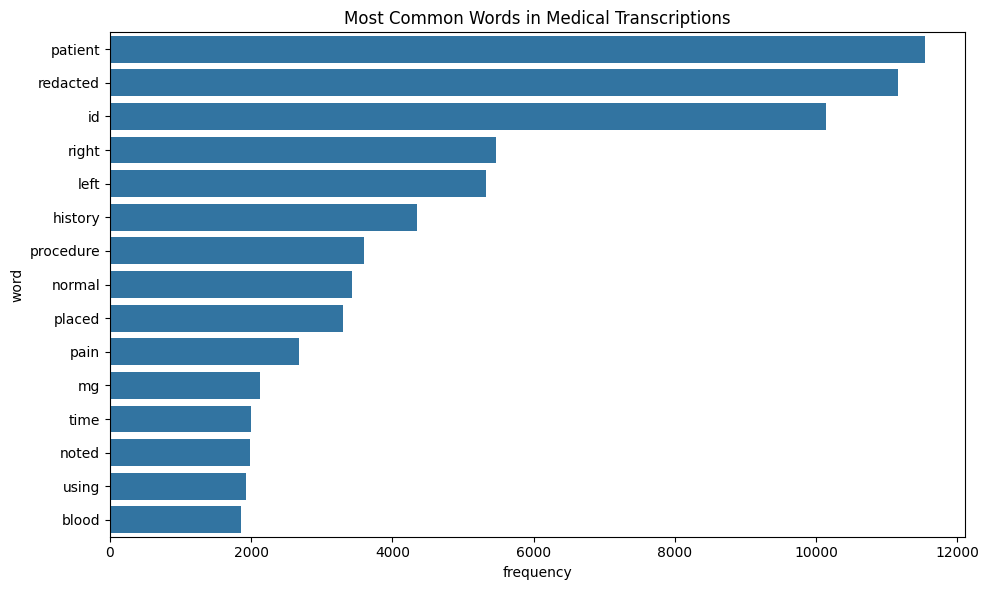


PART C - IMAGE DATA


README.md:   0%|          | 0.00/2.06k [00:00<?, ?B/s]

Chest X-ray dataset loaded in streaming mode.

Images inspected: 500

Class Distribution:
0    500
Name: count, dtype: int64


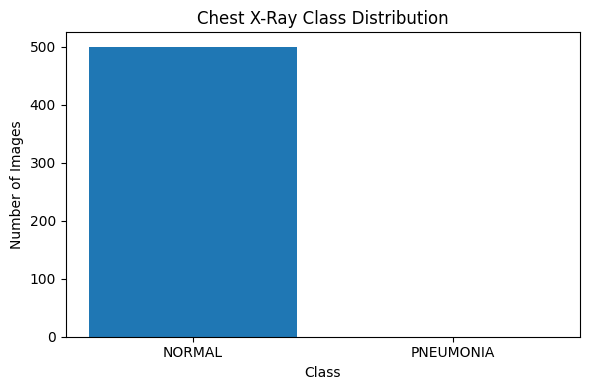


Average Image Width: 1681.024
Average Image Height: 1364.462
Average Pixel Intensity: 122.00787
Average Pixel Standard Deviation: 61.628345


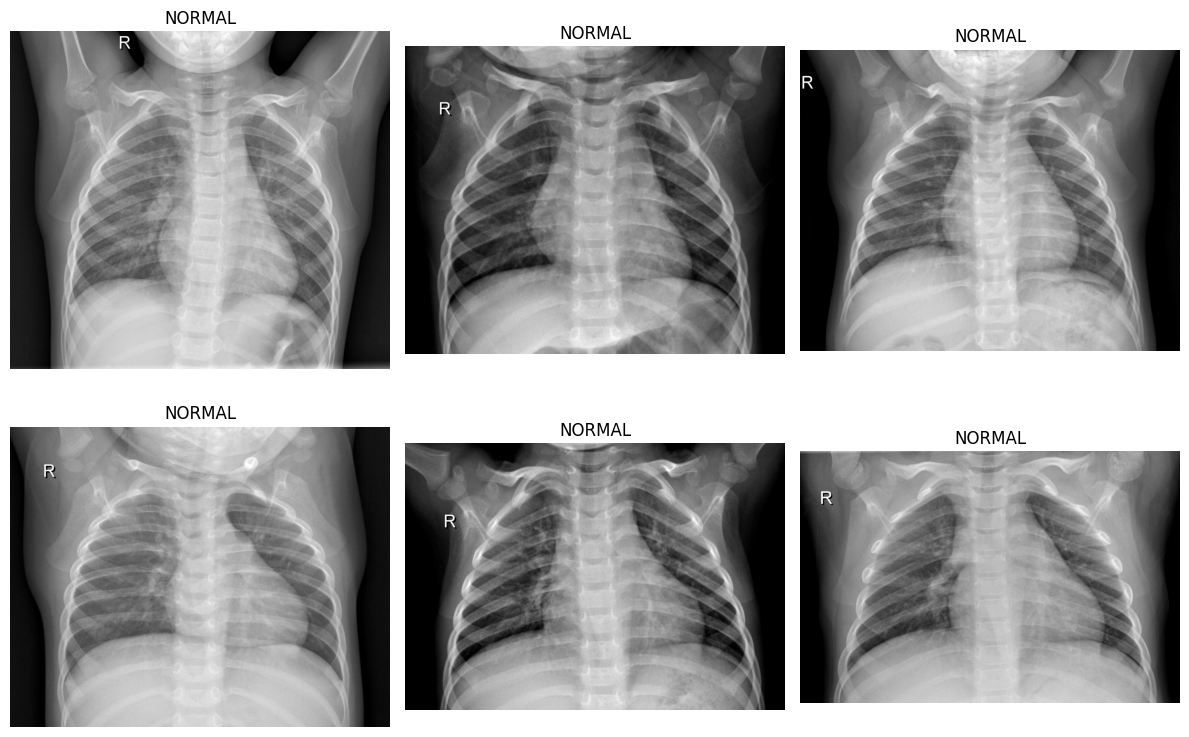


Processed Image Tensor Shape:
(224, 224, 1)
Minimum Pixel Value: 0.0
Maximum Pixel Value: 0.9764706


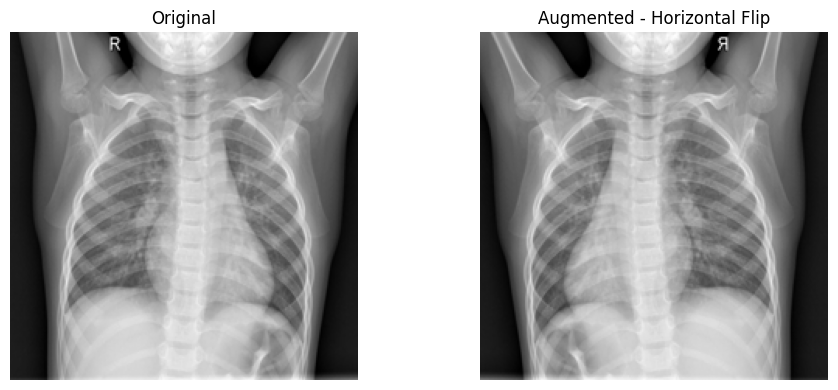


PART D - SIGNAL DATA

Record: 100
Sampling Frequency: 360
Number of Samples: 650000
Number of Channels: 2
Signal Names: ['MLII', 'V5']

ECG Mean: -0.3062989769230769
ECG Standard Deviation: 0.19319954213721688
ECG Minimum: -2.715
ECG Maximum: 1.435


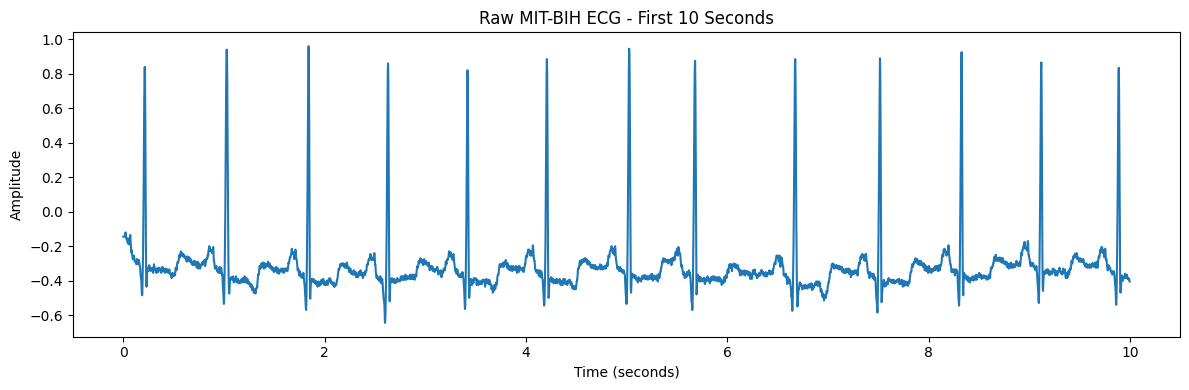

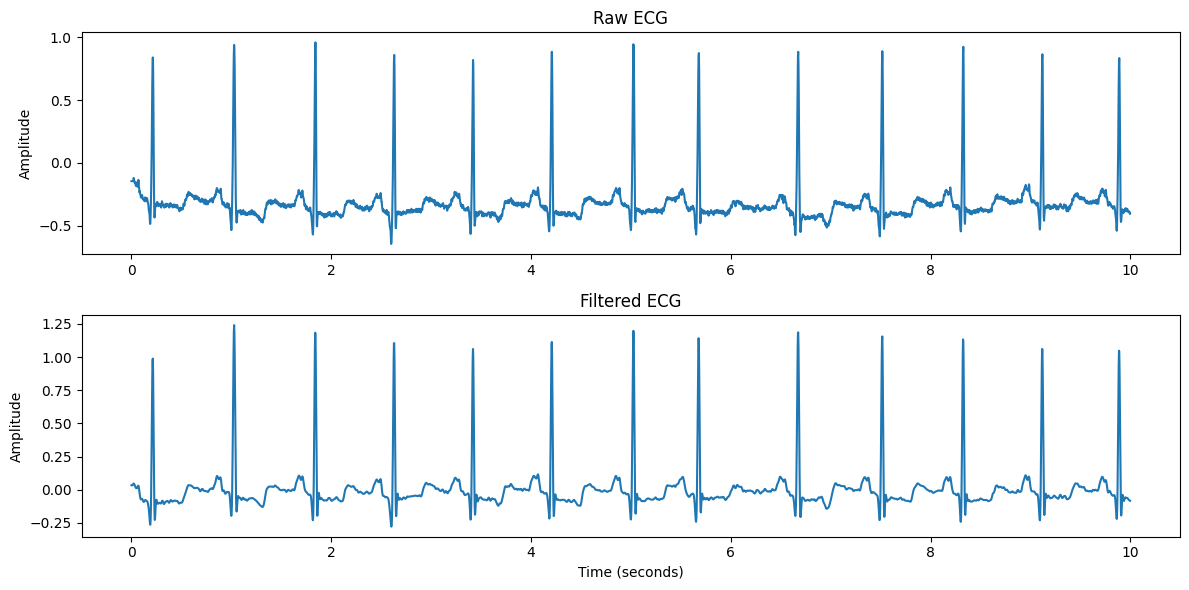


Signal Window Tensor Shape:
(3610, 360)


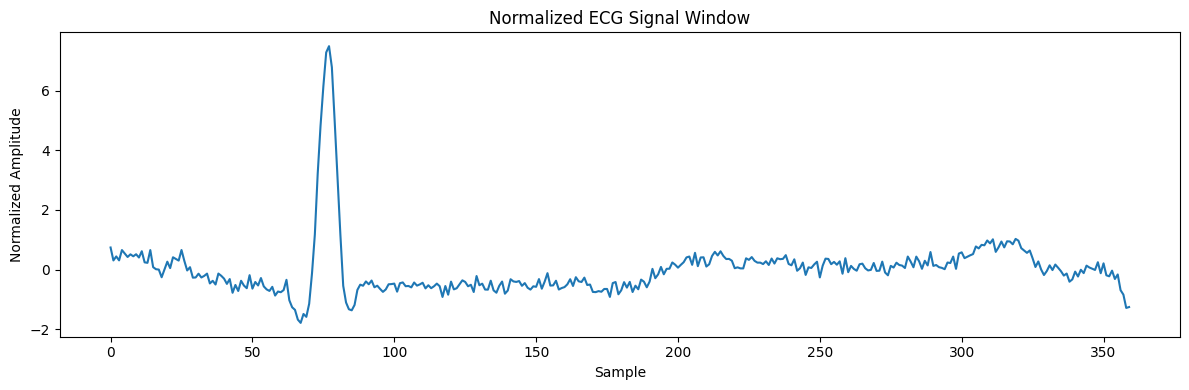

In [1]:
%pip install -q datasets wfdb

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from PIL import Image
from scipy.signal import butter, filtfilt

import wfdb
from datasets import load_dataset

print("Libraries imported successfully.")

# PART A - TABULAR DATA

url = (
    "https://raw.githubusercontent.com/"
    "jbrownlee/Datasets/master/"
    "pima-indians-diabetes.data.csv"
)

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(
    url,
    header=None,
    names=columns
)

print("\nFirst 5 rows:")
print(df.head())

print("\nShape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())


# Class imbalance

print("\nClass Distribution:")
print(df["Outcome"].value_counts())

print("\nClass Percentage:")
print(
    df["Outcome"]
    .value_counts(normalize=True)
    .mul(100)
)

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Outcome"
)

plt.title("Pima Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()


# Healthcare-specific cleaning

zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("\nZero Values Before Cleaning:")
print(
    (df[zero_columns] == 0).sum()
)

df[zero_columns] = df[zero_columns].replace(
    0,
    np.nan
)

print("\nMissing Values After Converting Zero to NaN:")
print(df.isnull().sum())


# Median imputation

for column in zero_columns:
    df[column] = df[column].fillna(
        df[column].median()
    )

print("\nMissing Values After Imputation:")
print(df.isnull().sum())


# EDA

numeric_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

df[numeric_columns].hist(
    figsize=(14, 10)
)

plt.suptitle(
    "Pima Dataset - Numerical Feature Distributions"
)

plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[numeric_columns]
)

plt.title("Pima Dataset - Boxplots")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="viridis",
    fmt=".2f"
)

plt.title("Pima Dataset Correlation Heatmap")

plt.tight_layout()
plt.show()


# Feature engineering

df["Preg_Cat"] = pd.cut(
    df["Pregnancies"],
    bins=[-1, 2, 6, np.inf],
    labels=["Low", "Medium", "High"]
)

print("\nPregnancy Categories:")
print(df["Preg_Cat"].value_counts())


# Feature selection

X = df.drop(
    columns=["Outcome", "Preg_Cat"]
)

y = df["Outcome"]

selector = SelectKBest(
    score_func=f_classif,
    k=5
)

selector.fit(X, y)

selected_features = X.columns[
    selector.get_support()
]

print("\nSelected Features:")
print(list(selected_features))


# T-test

healthy = df[
    df["Outcome"] == 0
]["Glucose"]

diabetic = df[
    df["Outcome"] == 1
]["Glucose"]

t_stat, p_value_t = stats.ttest_ind(
    healthy,
    diabetic,
    equal_var=False
)

print("\nIndependent T-Test")
print("T-statistic:", round(t_stat, 4))
print("P-value:", p_value_t)

if p_value_t < 0.05:
    print("Result: Reject the null hypothesis.")
else:
    print("Result: Fail to reject the null hypothesis.")


# Chi-square test

contingency_table = pd.crosstab(
    df["Preg_Cat"],
    df["Outcome"]
)

print("\nContingency Table:")
print(contingency_table)

chi2, p_value_chi, dof, expected = (
    stats.chi2_contingency(
        contingency_table
    )
)

print("\nChi-Square Test")
print("Chi-square:", round(chi2, 4))
print("P-value:", p_value_chi)
print("Degrees of freedom:", dof)

if p_value_chi < 0.05:
    print("Result: Reject the null hypothesis.")
else:
    print("Result: Fail to reject the null hypothesis.")


# ANOVA

anova_model = ols(
    "BMI ~ C(Preg_Cat)",
    data=df
).fit()

anova_table = sm.stats.anova_lm(
    anova_model,
    typ=2
)

print("\nANOVA - BMI across Pregnancy Categories")
print(anova_table)

# PART B - TEXTUAL DATA

print("\n" + "=" * 70)
print("PART B - TEXTUAL DATA")
print("=" * 70)


MTSAMPLES_URL = (
    "https://raw.githubusercontent.com/"
    "aneuraz/mtsamplesFR/master/data/mtsamples.csv"
)

df_text = pd.read_csv(
    MTSAMPLES_URL
)

print("\nFirst 5 rows:")
print(df_text.head())

print("\nShape:")
print(df_text.shape)

print("\nColumns:")
print(df_text.columns.tolist())


# Keep required columns

df_text = df_text[
    [
        "transcription",
        "medical_specialty"
    ]
].dropna(
    subset=["transcription"]
).drop_duplicates(
    subset=["transcription"]
).copy()

print("\nShape After Cleaning:")
print(df_text.shape)

print("\nMissing Values:")
print(df_text.isnull().sum())


# Text EDA

print("\nMedical Specialty Distribution:")
print(
    df_text["medical_specialty"]
    .value_counts()
)


plt.figure(figsize=(12, 7))

df_text[
    "medical_specialty"
].value_counts().head(15).plot(
    kind="bar"
)

plt.title("Top 15 Medical Specialties")
plt.xlabel("Medical Specialty")
plt.ylabel("Number of Transcriptions")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()


df_text["text_length"] = (
    df_text["transcription"]
    .astype(str)
    .apply(len)
)

print(
    "\nAverage Transcription Length:",
    df_text["text_length"].mean()
)

print(
    "Maximum Transcription Length:",
    df_text["text_length"].max()
)

print(
    "Minimum Transcription Length:",
    df_text["text_length"].min()
)


plt.figure(figsize=(8, 5))

plt.hist(
    df_text["text_length"],
    bins=30
)

plt.title("Distribution of Transcription Length")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Transcriptions")

plt.tight_layout()
plt.show()


# PHI removal

def remove_phi(text):

    text = str(text)

    text = re.sub(
        r"\b\d{3}-\d{2}-\d{4}\b",
        "[REDACTED_SSN]",
        text
    )

    text = re.sub(
        r"\b(?:\+?\d{1,3}[-.\s]?)?"
        r"\(?\d{3}\)?[-.\s]\d{3}[-.\s]\d{4}\b",
        "[REDACTED_PHONE]",
        text
    )

    text = re.sub(
        r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b",
        "[REDACTED_DATE]",
        text
    )

    text = re.sub(
        r"\b\d{4}-\d{1,2}-\d{1,2}\b",
        "[REDACTED_DATE]",
        text
    )

    text = re.sub(
        r"\b[A-Za-z0-9._%+-]+@"
        r"[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
        "[REDACTED_EMAIL]",
        text
    )

    text = re.sub(
        r"\b(?:patient|pt)\s*(?:id|no|number)?"
        r"\s*[:#]?\s*[A-Za-z0-9-]+\b",
        "Patient [REDACTED_ID]",
        text,
        flags=re.IGNORECASE
    )

    return text


df_text["phi_removed"] = (
    df_text["transcription"]
    .apply(remove_phi)
)


# Text cleaning

def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


df_text["cleaned_text"] = (
    df_text["phi_removed"]
    .apply(clean_text)
)


print("\nExample After PHI Removal:")
print(
    df_text[
        [
            "transcription",
            "phi_removed"
        ]
    ].head(3)
)


# Tokenization

df_text["tokens"] = (
    df_text["cleaned_text"]
    .apply(lambda x: x.split())
)

df_text["token_count"] = (
    df_text["tokens"]
    .apply(len)
)

print(
    "\nAverage Number of Tokens:",
    df_text["token_count"].mean()
)


# TF-IDF

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=1000
)

X_text_tfidf = tfidf.fit_transform(
    df_text["cleaned_text"]
)

print(
    "\nTF-IDF Matrix Shape:"
)

print(
    X_text_tfidf.shape
)


# Most common words

count_vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20
)

word_matrix = count_vectorizer.fit_transform(
    df_text["cleaned_text"]
)

word_counts = np.asarray(
    word_matrix.sum(axis=0)
).ravel()

words = count_vectorizer.get_feature_names_out()

word_frequency = pd.DataFrame(
    {
        "word": words,
        "frequency": word_counts
    }
).sort_values(
    "frequency",
    ascending=False
)

print("\nMost Common Words:")
print(word_frequency.head(20))


plt.figure(figsize=(10, 6))

sns.barplot(
    data=word_frequency.head(15),
    x="frequency",
    y="word"
)

plt.title("Most Common Words in Medical Transcriptions")

plt.tight_layout()
plt.show()

# PART C - IMAGE DATA

print("\n" + "=" * 70)
print("PART C - IMAGE DATA")
print("=" * 70)

image_dataset = load_dataset(
    "hf-vision/chest-xray-pneumonia",
    split="train",
    streaming=True
)

print("Chest X-ray dataset loaded in streaming mode.")


# Collect a small sample only

image_samples = []

for item in image_dataset:

    image_samples.append(item)

    if len(image_samples) >= 500:
        break


print(
    "\nImages inspected:",
    len(image_samples)
)


# Class distribution in inspected sample

image_labels = [
    item["label"]
    for item in image_samples
]

label_counts = pd.Series(
    image_labels
).value_counts().sort_index()

print("\nClass Distribution:")
print(label_counts)


plt.figure(figsize=(6, 4))

plt.bar(
    ["NORMAL", "PNEUMONIA"],
    [
        label_counts.get(0, 0),
        label_counts.get(1, 0)
    ]
)

plt.title("Chest X-Ray Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()


# Image EDA

image_widths = []
image_heights = []
image_means = []
image_stds = []


for item in image_samples:

    img = item["image"].convert("L")

    arr = np.array(
        img,
        dtype=np.float32
    )

    image_widths.append(img.width)
    image_heights.append(img.height)
    image_means.append(arr.mean())
    image_stds.append(arr.std())


print(
    "\nAverage Image Width:",
    np.mean(image_widths)
)

print(
    "Average Image Height:",
    np.mean(image_heights)
)

print(
    "Average Pixel Intensity:",
    np.mean(image_means)
)

print(
    "Average Pixel Standard Deviation:",
    np.mean(image_stds)
)


# Display sample X-rays

plt.figure(figsize=(12, 8))

for i in range(6):

    item = image_samples[i]

    img = item["image"].convert("L")

    plt.subplot(2, 3, i + 1)

    plt.imshow(
        img,
        cmap="gray"
    )

    if item["label"] == 0:
        title = "NORMAL"
    else:
        title = "PNEUMONIA"

    plt.title(title)
    plt.axis("off")


plt.tight_layout()
plt.show()


# Image preprocessing

def preprocess_xray(
    image,
    target_size=(224, 224)
):

    img = image.convert("L")

    pixel_data = np.array(img)

    clean_img = Image.fromarray(
        pixel_data
    )

    clean_img = clean_img.resize(
        target_size
    )

    image_array = np.array(
        clean_img,
        dtype=np.float32
    )

    image_array = (
        image_array / 255.0
    )

    augmented = np.fliplr(
        image_array
    )

    tensor = np.expand_dims(
        augmented,
        axis=-1
    )

    return tensor


example_image = image_samples[0]["image"]

processed_image = preprocess_xray(
    example_image
)

print(
    "\nProcessed Image Tensor Shape:"
)

print(
    processed_image.shape
)

print(
    "Minimum Pixel Value:",
    processed_image.min()
)

print(
    "Maximum Pixel Value:",
    processed_image.max()
)


# Image augmentation

original = example_image.convert("L")

original_array = np.array(
    original.resize((224, 224)),
    dtype=np.float32
) / 255.0

flipped = np.fliplr(
    original_array
)


plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)

plt.imshow(
    original_array,
    cmap="gray"
)

plt.title("Original")
plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    flipped,
    cmap="gray"
)

plt.title("Augmented - Horizontal Flip")
plt.axis("off")

plt.tight_layout()
plt.show()

# PART D - SIGNAL DATA

print("\n" + "=" * 70)
print("PART D - SIGNAL DATA")
print("=" * 70)

record = wfdb.rdrecord(
    "100",
    pn_dir="mitdb"
)

print("\nRecord: 100")
print("Sampling Frequency:", record.fs)
print("Number of Samples:", record.sig_len)
print("Number of Channels:", record.n_sig)
print("Signal Names:", record.sig_name)


ecg = record.p_signal[:, 0]

fs = record.fs


# Signal EDA

print("\nECG Mean:", np.mean(ecg))
print("ECG Standard Deviation:", np.std(ecg))
print("ECG Minimum:", np.min(ecg))
print("ECG Maximum:", np.max(ecg))


# First 10 seconds

samples_10_sec = int(
    fs * 10
)

time = np.arange(
    samples_10_sec
) / fs


plt.figure(figsize=(12, 4))

plt.plot(
    time,
    ecg[:samples_10_sec]
)

plt.title("Raw MIT-BIH ECG - First 10 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()


# Noise removal

def butter_bandpass_filter(
    signal,
    lowcut=0.5,
    highcut=40.0,
    fs=360,
    order=4
):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(
        order,
        [low, high],
        btype="band"
    )

    return filtfilt(
        b,
        a,
        signal
    )


filtered_ecg = butter_bandpass_filter(
    ecg,
    fs=fs
)


# Raw vs filtered

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)

plt.plot(
    time,
    ecg[:samples_10_sec]
)

plt.title("Raw ECG")
plt.ylabel("Amplitude")


plt.subplot(2, 1, 2)

plt.plot(
    time,
    filtered_ecg[:samples_10_sec]
)

plt.title("Filtered ECG")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()


# Signal augmentation

noise = np.random.normal(
    loc=0,
    scale=0.02,
    size=filtered_ecg.shape
)

augmented_ecg = (
    filtered_ecg + noise
)


# Signal segmentation

def create_signal_windows(
    signal,
    window_size=360,
    stride=180
):

    windows = []

    for start in range(
        0,
        len(signal) - window_size + 1,
        stride
    ):

        window = signal[
            start:
            start + window_size
        ]

        mean = np.mean(window)
        std = np.std(window)

        normalized = (
            window - mean
        ) / (
            std + 1e-8
        )

        windows.append(
            normalized
        )

    return np.array(windows)


signal_windows = create_signal_windows(
    augmented_ecg
)

print(
    "\nSignal Window Tensor Shape:"
)

print(
    signal_windows.shape
)


# Display one signal window

plt.figure(figsize=(12, 4))

plt.plot(
    signal_windows[0]
)

plt.title(
    "Normalized ECG Signal Window"
)

plt.xlabel("Sample")
plt.ylabel("Normalized Amplitude")

plt.tight_layout()
plt.show()
